# Chapter 5 — Continuous Random Variables

Densities, area as probability, and the exponential model of waiting times.

| Section | What it covers |
|---|---|
| 5.1 | Density and area |
| 5.2 | The exponential distribution |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Continuous Random Variables](https://khh-aka-lucifer.github.io/statLab/chapters/continuous-random-variables/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## From bars to a curve

A **continuous** random variable can take any value in a range, such as a temperature, a waiting
time or a distance. That breaks the machinery of Chapter 4, because asking for the probability that
tomorrow's high is exactly 16.0000... °C gives zero. There are infinitely many values and no single
one has any mass.

So we stop asking about points and start asking about intervals, and the tool for that is a curve.

In [2]:
weather = pd.read_csv(DATA / "seattle-weather.csv", parse_dates=["date"])
temp = weather["temp_max"]

print(f"{len(temp)} days, from {temp.min():.1f} to {temp.max():.1f} °C")

1461 days, from -1.6 to 35.6 °C


## 5.1 Density and area

A histogram counts days per bin, so its bar heights depend on how many days you happened to collect
and how wide you made the bins. Divide each height by $n$ and by the bin width and that goes away.
What is left is a **density**, and the defining property is that the *area* of the bars is 1.

Area, not height, is the probability.

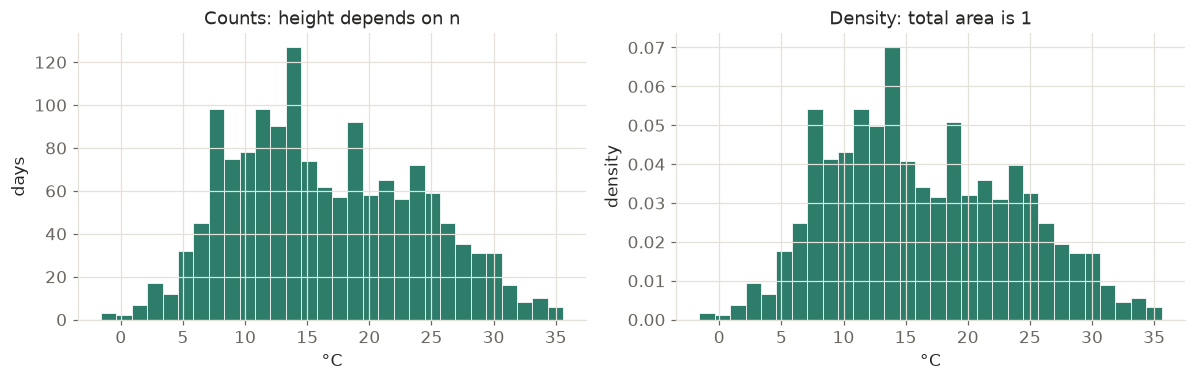

In [3]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

left.hist(temp, bins=30, color=C["accent"], edgecolor="white", linewidth=0.5)
left.set_title("Counts: height depends on n"); left.set_ylabel("days"); left.set_xlabel("°C")

right.hist(temp, bins=30, density=True, color=C["accent"], edgecolor="white", linewidth=0.5)
right.set_title("Density: total area is 1"); right.set_ylabel("density"); right.set_xlabel("°C")

plt.tight_layout()
plt.show()

In [4]:
heights, edges = np.histogram(temp, bins=30, density=True)
widths = np.diff(edges)

print(f"sum of (height x width) = {(heights * widths).sum():.10f}")

sum of (height x width) = 1.0000000000


Now probabilities are areas you can shade. What fraction of days get warmer than 25 °C? Count them,
then read the same answer off the picture.

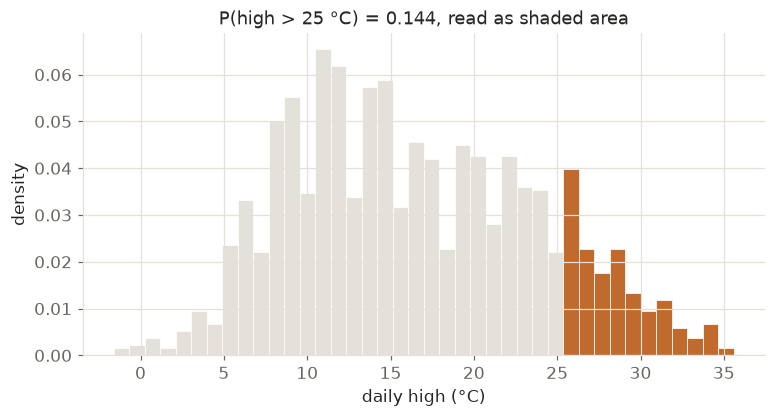

counted directly: 211 of 1461 days = 0.1444


In [5]:
threshold = 25
share = (temp > threshold).mean()

fig, ax = plt.subplots(figsize=(8, 3.8))
counts, edges, patches = ax.hist(temp, bins=40, density=True, color=C["line"],
                                 edgecolor="white", linewidth=0.5)
for patch, left_edge in zip(patches, edges[:-1]):
    if left_edge >= threshold:
        patch.set_facecolor(C["warn"])

ax.set_xlabel("daily high (°C)"); ax.set_ylabel("density")
ax.set_title(f"P(high > {threshold} °C) = {share:.3f}, read as shaded area")
plt.show()

print(f"counted directly: {(temp > threshold).sum()} of {len(temp)} days = {share:.4f}")

In [ ]:
# Your turn.
# 1. What fraction of days fall between 10 and 20 degrees? Count it.
# 2. Shade that band on a density histogram and check the picture agrees.
# 3. What is P(temp_max == 15.0) exactly? Compute it, then explain the answer in a comment.

...

## 5.2 The exponential distribution

The **exponential** describes waiting times when events arrive at a constant average rate. Its
density is $f(w) = \lambda e^{-\lambda w}$, and its mean wait is $1/\lambda$.

Real waiting times are all around you. Here is one: how many days pass between heavy-rain days in
Seattle?

In [6]:
wet_days = weather.index[weather["precipitation"] > 10].to_numpy()
gaps = np.diff(wet_days)                         # days between one soaking and the next

print(f"{len(gaps)} gaps between heavy-rain days")
print(f"mean gap  = {gaps.mean():.2f} days")
print(f"so lambda = 1/mean = {1/gaps.mean():.4f} per day")
print(f"median gap = {np.median(gaps):.0f} days, much shorter than the mean, which is the tell for a right skew")

143 gaps between heavy-rain days
mean gap  = 10.13 days
so lambda = 1/mean = 0.0987 per day
median gap = 3 days, much shorter than the mean, which is the tell for a right skew


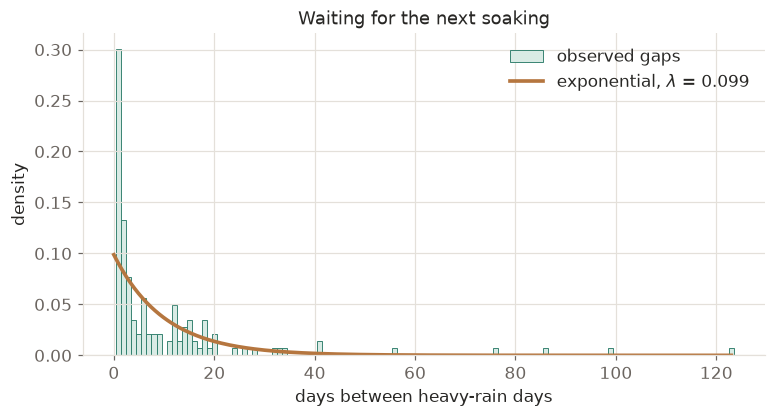

In [7]:
lam = 1 / gaps.mean()
grid = np.linspace(0, gaps.max(), 300)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(gaps, bins=np.arange(0.5, gaps.max() + 1.5, 1), density=True,
        color=C["accent_soft"], edgecolor=C["accent"], linewidth=0.6, label="observed gaps")
ax.plot(grid, lam * np.exp(-lam * grid), color=C["cat2"], lw=2.4,
        label=rf"exponential, $\lambda$ = {lam:.3f}")

ax.set_xlabel("days between heavy-rain days"); ax.set_ylabel("density")
ax.set_title("Waiting for the next soaking")
ax.legend()
plt.show()

Not a bad fit for something nobody designed. Short gaps are common, long gaps are rare, and the
decay is roughly exponential.

### Memorylessness

The exponential has a strange property. It is **memoryless**, which means that having already
waited tells you nothing about how much longer you will wait.

$$P(W > s + t \mid W > s) = P(W > t)$$

Check it on the real gaps rather than taking it on trust.

In [8]:
def survival(data, t):
    return (data > t).mean()

print("P(wait more than 3 more days | already waited s days)")
for s in [0, 2, 5, 10]:
    remaining = gaps[gaps > s] - s
    print(f"  already waited {s:2d} days -> {survival(remaining, 3):.3f}")
print()
print(f"and from a fresh start, P(wait > 3) = {survival(gaps, 3):.3f}")

P(wait more than 3 more days | already waited s days)
  already waited  0 days -> 0.490
  already waited  2 days -> 0.765
  already waited  5 days -> 0.774
  already waited 10 days -> 0.756

and from a fresh start, P(wait > 3) = 0.490


The numbers hover around the same value no matter how long you have already waited. The rain has no
memory of how long it has been dry.

This is genuinely counter-intuitive and it is also genuinely wrong for many things. Buses run on
schedules, so a bus that is already ten minutes late is *more* likely to arrive soon. Machines wear
out, so an old part is more likely to fail than a new one. The exponential is the right model only
when the thing you are waiting for does not age, and radioactive decay and, roughly, rainstorms
qualify.

In [ ]:
# Your turn.
# Repeat the whole section for a lower threshold: gaps between days with ANY rain (> 0 mm).
# 1. Compute the gaps and lambda.
# 2. Overlay the exponential density.
# 3. Test memorylessness.
# Does the fit get better or worse, and can you say why?

...

## Exercises

1. **The other direction.** Fit an exponential to the *dry spell* lengths, meaning runs of
   consecutive days with zero rain. Is a dry spell more or less memoryless than a wet gap?

2. **Area between two points.** Use `stats.expon.cdf` to compute $P(3 < W < 10)$ for the fitted
   $\lambda$, then count the same thing directly in `gaps`. How close are they, and is the
   difference big enough to matter?

3. **The mean is not the middle.** For an exponential, the median is $\ln(2)/\lambda$, which is about
   69 % of the mean. Check that against the real gaps. Which would you quote to someone planning a
   picnic?

4. **Uniform for comparison.** The wind column is much less skewed. Fit both a uniform and a normal
   density to it and overlay them. Which is less wrong, and how would you decide that without
   eyeballing it?

5. **Simulate and recover.** Draw 500 waits from `rng.exponential(scale=1/lam)`, then estimate
   $\lambda$ back from your simulated data. Repeat 200 times and look at the spread of your
   estimates. You have just invented the sampling distribution, which is Chapter 7.

## What you should take away

For a continuous variable, probability is area under a density curve, never the height of it, and
never the probability of a single point, which is always zero.

The exponential models waits when events arrive at a constant rate, and its memorylessness is both
its signature and the thing that tells you when not to use it. Real data lets you check the fit
rather than assume it, and the Seattle gaps show a model that works well enough to be useful while
still being visibly imperfect.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*